## what does the wedding agent do?  
It's an orchestrator for a tiny "wedding-planning company". In one short user sentence it:  
  
Extracts the 4 facts it needs — update_state(London, Paris, 100, jazz) (reads the words out of your sentence, no follow-up questions).  
Delegates to 3 specialists (each a sub-agent):  
🛫 travel agent → Kiwi → real flight options  
🏨 venue agent → Tavily web search → venues for location + capacity  
🎵 playlist agent → SQL database → songs for the genre + total duration/cost  
Merges the 3 answers into one coordinated wedding plan (flights + venues + playlist + next steps).  
  
In one sentence: "The agent plans a wedding by gathering facts from your sentence, validating them through live searches (flights, venues) and a database  (playlist), and presenting you with a complete plan." Swap the tools + prompts and it becomes any planning agent (conference, trip, event…).  

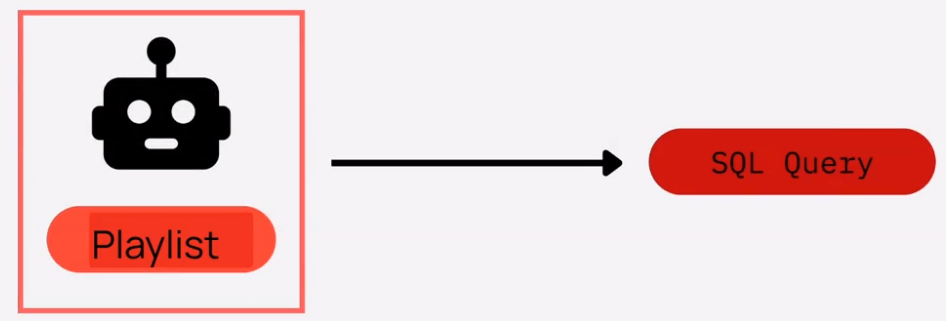

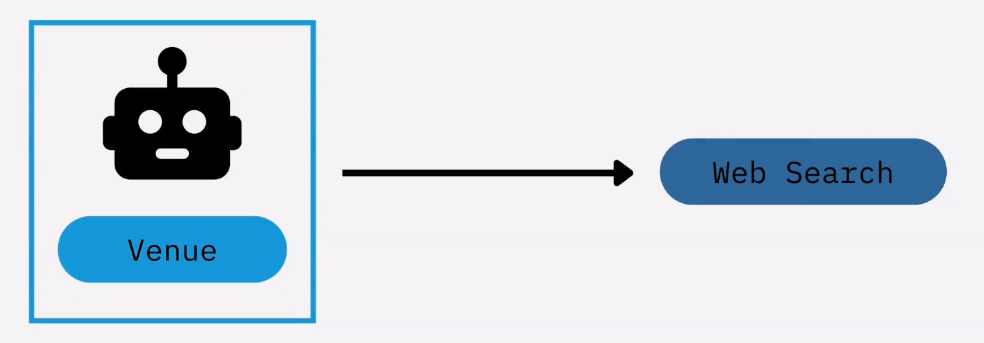

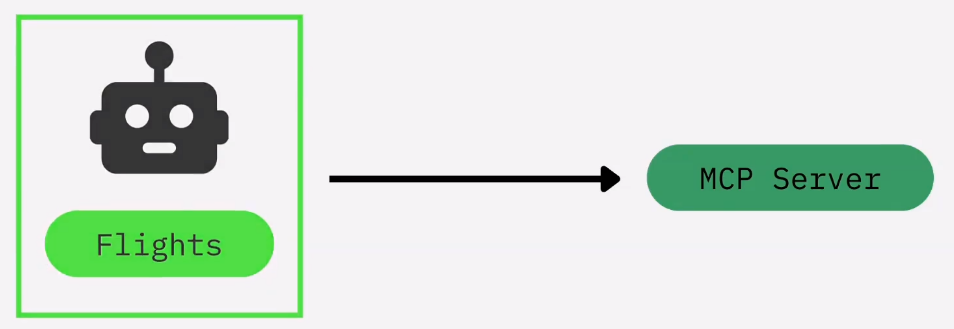

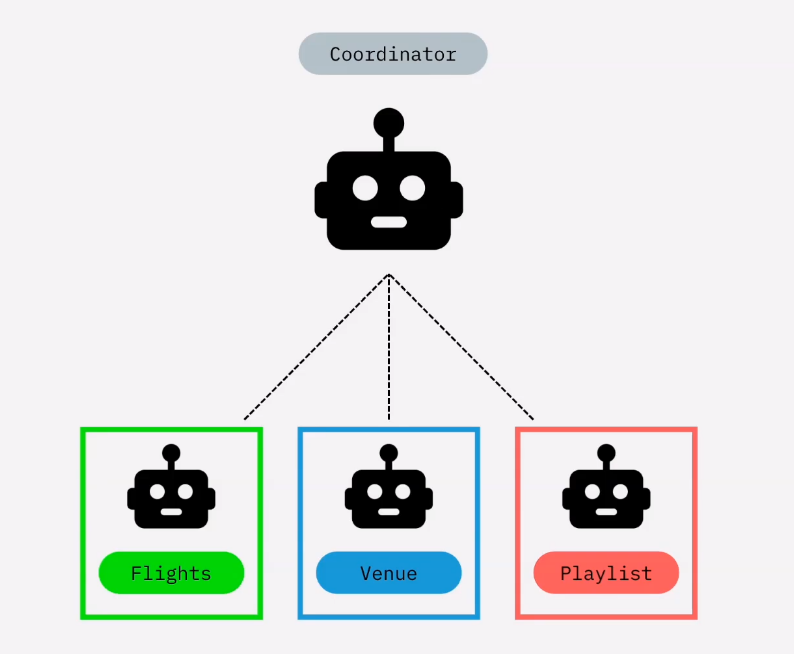

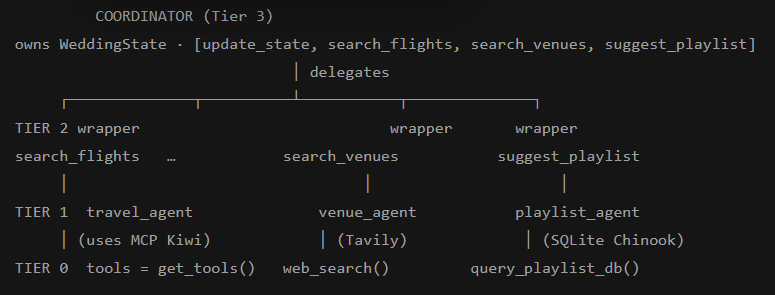

### Step 0:
##### Wedding Agent = brain + hands rules + suitcase
##### LOOP: model ⇄ tools until final answer
##### 4 tiers: tools → subagents → wrappers → coordinator

### Step 1: creating the model

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [23]:
import os
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="gemini-3.1-flash-lite",
    model_provider="google-genai",
    api_key=os.getenv("GOOGLE_API_KEY"),
)

### Step 1 : MCP remote kiwi server 

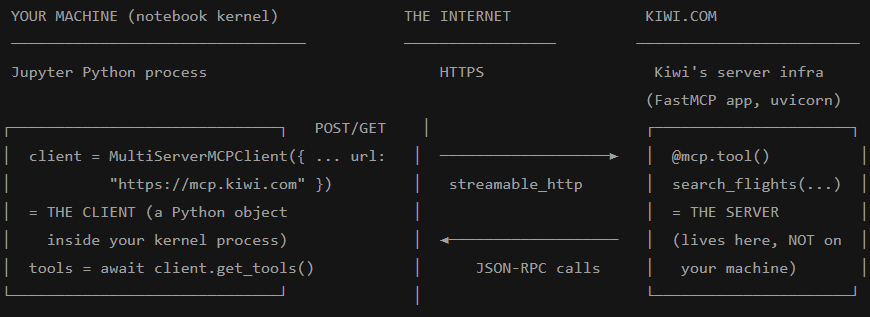

**Kiwi.com = a flight search engine (compares hundreds of airlines). You give: origin, destination, date (and filters), it returns: flights with price, duration, airports, booking links — exactly what a wedding "travel specialist" needs, live.**

In [24]:
import asyncio

async def get_tools_with_retry(client, attempts: int = 4, delay: float = 4.0):
    """Kiwi's free MCP server is occasionally 503. Retry with backoff."""
    for a in range(attempts):
        try:
            return await client.get_tools()
        except Exception as e:
            if a == attempts - 1:
                raise
            print(f"MCP retry {a + 1}: {type(e).__name__} - {str(e)[:80]}")
            await asyncio.sleep(delay * (a + 1))


In [25]:
from langchain_mcp_adapters.client import MultiServerMCPClient
client = MultiServerMCPClient({"travel_server": {"transport": "streamable_http",
                                                "url": "https://mcp.kiwi.com"}})
tools = await get_tools_with_retry(client)          # live flight-search catalog

### Step 2 : Tavily web search tool 

In [26]:
from tavily import TavilyClient
from langchain.tools import tool
tavily = TavilyClient()

@tool
def web_search(query: str, search_number: int, max_search_number: int) -> dict:
    """Search the web. Track your budget: search_number (start at 1) and max_search_number."""

    if search_number > max_search_number:
        return {"message": "Search limit reached. Summarize and answer."}
    try:
        return tavily.search(query)
    except Exception as e:
        return {"error": str(e)}

### Step 3:Local SQLite tool

In [27]:
from pathlib import Path
from langchain_community.utilities import SQLDatabase

# SQLite URI must start with sqlite:/// and be an absolute path (kernel cwd varies).
_db = next((p for p in [
    Path("/home/im_ane/lca-lc-foundations/notebooks/module-2/resources/Chinook.db"),
    Path.cwd() / "notebooks" / "module-2" / "resources" / "Chinook.db",
    Path.cwd() / "resources" / "Chinook.db",
] if p.exists()), None)
if _db is None:
    raise FileNotFoundError("Chinook.db not found -- kernel cwd: " + str(Path.cwd()))
db = SQLDatabase.from_uri(f"sqlite:///{_db}")

@tool
def query_playlist_db(query: str) -> str:
    """Query the database for playlist information."""
    try:
        return db.run(query)
    except Exception as e:
        return f"Error querying database: {e}"


### Step 4:State

In [28]:
from langchain.agents import AgentState
class WeddingState(AgentState):
    origin: str
    destination: str
    guest_count: str
    genre: str

### Step 5: Creating Sub-agents

In [29]:
from langchain.agents import create_agent


In [30]:
travel_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="""Travel agent.
Best flights (cheapest, shortest), no follow-up questions, retry on MCP failure."""
)

In [31]:
venue_agent = create_agent(
    model=model,
    tools=[web_search],
    system_prompt="""Venue specialist.
Best venue (cheapest, exact capacity, highest reviews), max 12 searches."""
)

In [32]:
playlist_agent = create_agent(
    model=model,
    tools=[query_playlist_db],
    system_prompt="""Playlist specialist.
    Discover schema first, keep trying until you find songs, compute total duration + cost."""
)

### Step 6:calling sub-agents

In [33]:
from langchain.tools import ToolRuntime
from langchain.messages import HumanMessage, ToolMessage
from langgraph.types import Command

import asyncio

@tool
async def search_flights(runtime: ToolRuntime) -> str:
    """Travel agent searches flights to the destination."""
    o, d = runtime.state["origin"], runtime.state["destination"]
    for a in range(3):
        try:
            r = await travel_agent.ainvoke({"messages": [HumanMessage(f"Find flights from {o} to {d}")]})
            return r["messages"][-1].content
        except Exception as e:
            if a == 2:
                return f"Flight search failed after retries: {e}"
            await asyncio.sleep(5 * (a + 1))

@tool
def search_venues(runtime: ToolRuntime) -> str:
    """Venue agent chooses the best venue for location + capacity."""
    dst, n = runtime.state["destination"], runtime.state["guest_count"]
    r = venue_agent.invoke({"messages": [HumanMessage(f"Find wedding venues in {dst} for {n} guests")]})
    return r["messages"][-1].content

@tool
def suggest_playlist(runtime: ToolRuntime) -> str:
    """Playlist agent curates a playlist for the given genre."""
    g = runtime.state["genre"]
    r = playlist_agent.invoke({"messages": [HumanMessage(f"Find {g} tracks for wedding playlist")]})
    return r["messages"][-1].content

@tool
def update_state(origin: str, destination: str, guest_count: str, genre: str, runtime: ToolRuntime) -> str:
    """Update the state when you know ALL values. Call this ALONE, must complete first."""
    return Command(update={"origin": origin, "destination": destination,
                              "guest_count": guest_count, "genre": genre,
                              "messages": [ToolMessage("Successfully updated state", tool_call_id=runtime.tool_call_id)]})



### Step 7:Create the main agent orchestrator

In [34]:
main_agent = create_agent(
    model=model,
    tools=[search_flights, search_venues, suggest_playlist, update_state],
    state_schema=WeddingState,
    system_prompt="""You are a wedding coordinator. First find all the info you need,
    then update the state. Once update_state has returned, delegate to your specialists
    for flights, venues, playlists. Then coordinate the perfect wedding."""
)

### test

In [35]:
from langchain.messages import HumanMessage

response = await main_agent.ainvoke(
    {
        "messages": [HumanMessage(content="I'm from Morocco and I'd like a wedding in uk old castle for 100 guests, classic vintage")],
    },
    config={"tags": ["WP"], "recursion_limit": 40},  #tag traces to make them easy to find in Langsmith. Increase number of steps the agent can take to 40.
)

In [38]:
from pprint import pprint

pprint(response)

{'destination': 'UK',
 'genre': 'classic vintage',
 'guest_count': '100',
 'messages': [HumanMessage(content="I'm from Morocco and I'd like a wedding in uk old castle for 100 guests, classic vintage", additional_kwargs={}, response_metadata={}, id='527913c4-070c-42d2-bb41-8da6dc43a76f'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'update_state', 'arguments': '{"origin": "Morocco", "destination": "UK", "guest_count": "100", "genre": "classic vintage"}'}, '__gemini_function_call_thought_signatures__': {'call_1346580': 'EnEKbwFpFH0ToeQ+G68eA4aPKXE0HQw1auaGKeCiS6KaBkU6ot4J09mnfxdEdSDHhrbP3Jfo2ZSgktvqEUETTgOvjhS2SbJesM62v/TpqmqPoJRZ7XnSYfmLzKEc/9L21gcyAIh91UFcZ0YkN1H4gQtImg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0d934-ec99-72c1-8c70-fd50deb06e71-0', tool_calls=[{'name': 'update_state', 'args': {'origin': 'Morocco', 'destination': 'UK